In [1]:
pip install numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.


# Bitcoin Price Prediction

In [16]:
import tkinter as tk
from tkinter import messagebox
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
import seaborn as sns

# Importing dataset
bitcoin_data = pd.read_csv(r"D:\Studies\Datasets\bit.csv")
bitcoin_data

,date,Open,High,Low,Close,Adj Close,Volume
0,01-01-2015,320.434998,320.434998,314.002991,314.248993,314.248993,8.036550e+06
1,02-01-2015,314.079010,315.838989,313.565002,315.032013,315.032013,7.860650e+06
2,03-01-2015,314.846008,315.149994,281.082001,281.082001,281.082001,3.305440e+07
3,04-01-2015,281.145996,287.230011,257.612000,264.195007,264.195007,5.562910e+07
4,05-01-2015,265.084015,278.341003,265.084015,274.473999,274.473999,4.396280e+07
...,...,...,...,...,...,...,...
3362,16-03-2024,69392.484380,70046.273440,64801.394530,65315.117190,65315.117190,4.684220e+10
3363,17-03-2024,65316.343750,68845.718750,64545.316410,68390.625000,68390.625000,4.471686e+10
3364,18-03-2024,68371.304690,68897.132810,66594.226560,67548.593750,67548.593750,4.926158e+10
3365,19-03-2024,67556.132810,68106.929690,61536.179690,61912.773440,61912.773440,7.421584e+10


In [17]:
bitcoin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3367 entries, 0 to 3366
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       3367 non-null   object 
 1   Open       3367 non-null   float64
 2   High       3367 non-null   float64
 3   Low        3367 non-null   float64
 4   Close      3367 non-null   float64
 5   Adj Close  3367 non-null   float64
 6   Volume     3367 non-null   float64
dtypes: float64(6), object(1)
memory usage: 184.3+ KB


In [18]:
bitcoin_data.isnull().sum()

date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [19]:
bitcoin_data.duplicated().sum()

0

In [20]:
bitcoin_data.isnull().any()

date         False
Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool

In [21]:
print(bitcoin_data.columns.tolist())

['date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [23]:
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['date'], dayfirst=True)

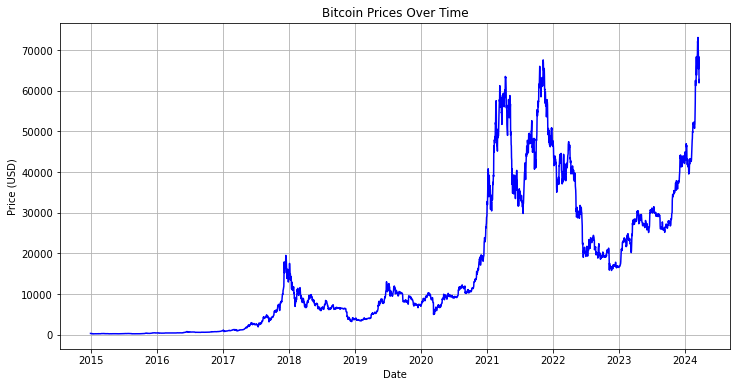

In [24]:
bitcoin_data.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(bitcoin_data.index.to_numpy(), bitcoin_data['Close'].to_numpy(), color='blue', linestyle='-')
plt.title('Bitcoin Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


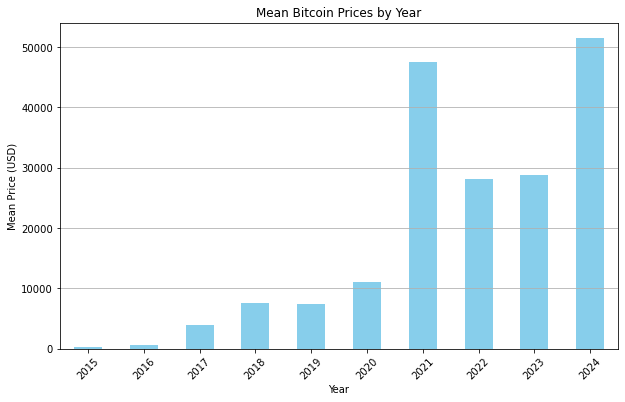

In [26]:
bitcoin_data['Year'] = bitcoin_data.index.year

mean_price_by_year = bitcoin_data.groupby('Year')['Close'].mean()

plt.figure(figsize=(10, 6))
mean_price_by_year.plot(kind='bar', color='skyblue')
plt.title('Mean Bitcoin Prices by Year')
plt.xlabel('Year')
plt.ylabel('Mean Price (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

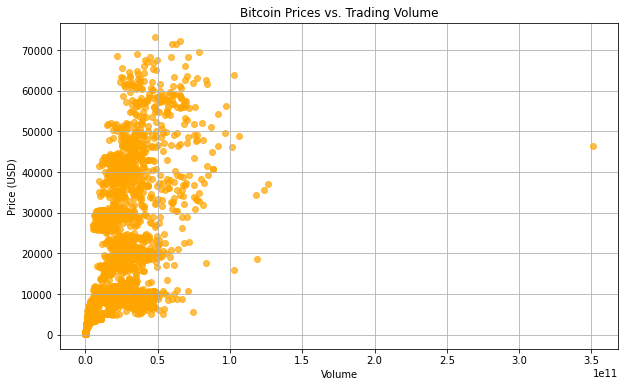

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(bitcoin_data['Volume'], bitcoin_data['Close'], color='orange', alpha=0.7)
plt.title('Bitcoin Prices vs. Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

In [28]:
print(bitcoin_data.columns)

Index(['date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year'], dtype='object')


In [29]:
bitcoin_data.columns = bitcoin_data.columns.str.strip().str.lower()
print(bitcoin_data.columns)

Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'year'], dtype='object')


In [31]:
# For example, if the column name is 'date' instead of 'Date':
# bitcoin_data['date'] = pd.to_datetime(bitcoin_data['date'])
# bitcoin_data['date'] = pd.to_datetime(bitcoin_data['Date'])
bitcoin_data['date'] = pd.to_datetime(bitcoin_data['date'], dayfirst=True)

In [33]:
# Preprocess the data
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['date'])
bitcoin_data['Date'] = bitcoin_data['Date'].dt.strftime('%Y%m%d').astype(int)
bitcoin_data = bitcoin_data.dropna()

In [35]:
# Split the data into features and target variable
x = bitcoin_data['Date'].values.reshape(-1, 1)
y = bitcoin_data['close'].values

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [37]:
pre = model.predict(x_test)

In [38]:
print(r2_score(pre,y_test))

0.4129742515831002


In [39]:
mode = RandomForestRegressor(n_estimators=100, random_state=42)
mode.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [42]:
pr = mode.predict(x_test)

In [43]:
print(r2_score(pr,y_test))

0.9969887134282691


In [44]:
# Function to predict Bitcoin price and calculate R2 score
def predict_and_calculate_r2(date_str, selected_country):
    try:
        date = datetime.strptime(date_str, '%Y-%m-%d')
        date = int(date.strftime('%Y%m%d'))
        predicted_price = mode.predict([[date]])
        y_pred = mode.predict(x_test)
        r2 = r2_score(y_test, y_pred)
        conversion_rate = conversion_rates.get(selected_country, 1)
        predicted_price_country = predicted_price[0] * conversion_rate
        return predicted_price[0], predicted_price_country, r2
    except ValueError:
        messagebox.showerror("Error", "Invalid date format. Please use YYYY-MM-DD.")

# Function to handle prediction button click
def predict():
    date_str = date_entry.get()
    selected_country = country_listbox.get(tk.ACTIVE)
    if date_str:
        predicted_price_usd, predicted_price_country, r2 = predict_and_calculate_r2(date_str, selected_country)
        messagebox.showinfo("Prediction", f"The predicted Bitcoin price in {selected_country} on {date_str} is ${predicted_price_usd:.2f} (USD)\n{predicted_price_country:.2f} ({selected_country})\nR2 Score: {r2:.2f}")
    else:
        messagebox.showerror("Error", "Please enter a date.")

# Currency conversion rates
conversion_rates = {
    "USD": 1,
    "INR": 75,  # Example conversion rate for Indian Rupees
    "Canada": 1.25,  # Example conversion rate for Canadian Dollars
    "Brazil": 5.2,   # Example conversion rate for Brazilian Real
    "China": 6.45,   # Example conversion rate for Chinese Yuan
    "Europe": 0.85   # Example conversion rate for Euro
    # Add more currency conversion rates as needed
}


In [ ]:
# Create GUI
root = tk.Tk()
root.title("Bitcoin Price Prediction")

bg_image = Image.open(r"C:\Users\HP\Downloads\images.jpeg")
bg_image_resized = bg_image.resize((root.winfo_screenwidth(), root.winfo_screenheight()))
bg_photo = ImageTk.PhotoImage(bg_image_resized)
bg_label = tk.Label(root, image=bg_photo)
bg_label.place(x=0, y=0, relwidth=1, relheight=1)

frame = tk.Frame(root)
frame.pack(padx=200, pady=200)

# Add heading
heading_label = tk.Label(frame, text="Bitcoin Price Prediction", font=("Century Schoolbook", 20))
heading_label.grid(row=0, column=0, columnspan=2, padx=5, pady=10)

# Add date label and entry
date_label = tk.Label(frame, text="Enter date (YYYY-MM-DD):", font=("Century Gothic", 12))
date_label.grid(row=1, column=0, padx=5, pady=5)
date_entry = tk.Entry(frame, font=("Arial", 12))
date_entry.grid(row=1, column=1, padx=5, pady=5)

# Add listbox for country selection
country_listbox = tk.Listbox(frame, font=("Arial", 12), height=7)
country_listbox.grid(row=2, column=0, columnspan=2, padx=5, pady=5)
countries = ["USD", "INR", "Canada", "Brazil", "China", "Europe"]  # Add more countries as needed
for country in countries:
    country_listbox.insert(tk.END, country)

# Add prediction button
predict_button = tk.Button(frame, text="Predict", command=predict, font=("Arial", 12))
predict_button.grid(row=3, column=0, columnspan=2, padx=5, pady=10)

root.mainloop()
